## **Customer Churn Analytics Platform**

## Problem Statement

Customer churn is a critical business challenge for subscription-based companies. Losing existing customers can result in significant revenue loss and increased customer acquisition costs.

The objective of this project is to analyze customer behavior, identify the factors associated with customer churn, estimate revenue impact, and provide business recommendations to improve customer retention.

## Project Objectives

* Analyze customer churn patterns.
* Identify key churn drivers.
* Evaluate the relationship between customer tenure and churn.
* Assess the impact of monthly charges on churn.
* Estimate revenue lost due to churn.
* Provide actionable business recommendations.


**Dataset Overview**

The Telco Customer Churn dataset contains customer demographic information, account details, subscribed services, billing information, and churn status.

**Dataset Information**

* Total Records: 7,043 customers
* Features: 21 columns
* Target Variable: Churn (Yes/No)

**Key Variables**
* tenure: Number of months the customer has stayed with the company
* MonthlyCharges: Monthly billing amount
* TotalCharges: Total amount charged to the customer
* Contract: Customer contract type
* PaymentMethod: Payment method used
* InternetService: Type of internet service subscribed
* Churn: Indicates whether the customer left the company

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [57]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.shape

(7043, 21)

# **Data Cleaning**

## Data Understanding and Quality Assessment

In this section, the dataset is examined to understand its structure, identify missing values, detect duplicate records, and verify data types before analysis.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors = 'coerce')

In [10]:
from sklearn.impute import SimpleImputer
sm = SimpleImputer(strategy = 'mean')
df[['TotalCharges']] = sm.fit_transform(df[['TotalCharges']])

### Data Cleaning Conclusion

The TotalCharges column was stored as an object data type due to blank values. It was converted to a numeric format, and missing values were imputed using the mean value to ensure data completeness.


# **EDA**


### Churn Distribution Analysis


---


This section examines the overall distribution of churned and retained customers to understand the magnitude of customer attrition.

In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
churn_rate = (df['Churn'].value_counts(normalize=True)['Yes'] * 100)
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


In [13]:
churn_rate = (df['Churn'].value_counts(normalize=True)['Yes'] * 100)
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


**Insight**

The overall customer churn rate is 26.54%, indicating that approximately 27 out of every 100 customers discontinue the service.

<Axes: xlabel='Churn', ylabel='count'>

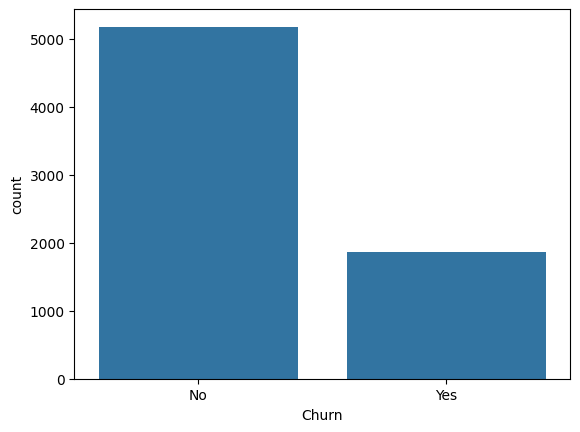

In [14]:
sns.countplot(x='Churn' , data = df)

Insight

---

The dataset contains both retained and churned customers, providing a balanced basis for churn analysis. The churn rate indicates the proportion of customers who have left the company.

# UNIVARIATE ANALYSIS

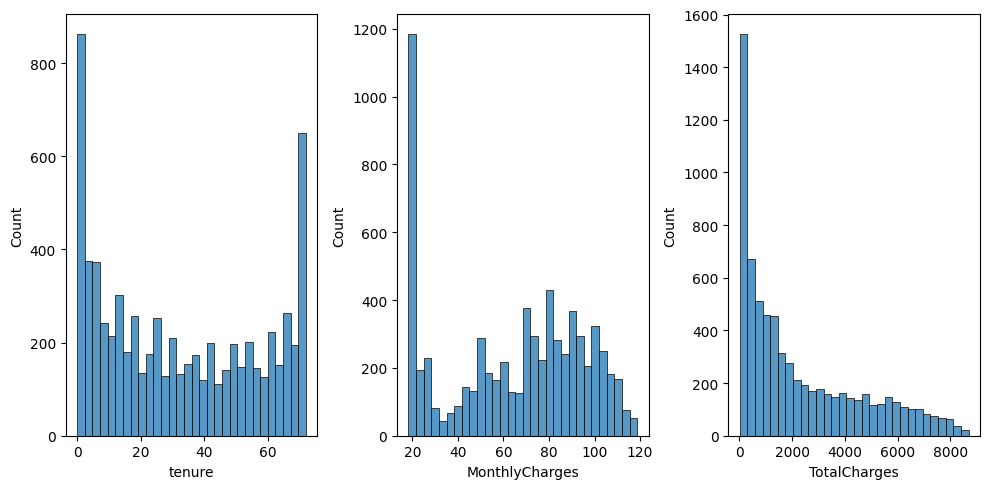

In [15]:
import matplotlib.pyplot as plt

fig , axes = plt.subplots(1, 3 , figsize = (10 , 5))

sns.histplot(df['tenure'] , bins = 30 , ax=axes[0])
sns.histplot(df['MonthlyCharges'] , bins = 30 , ax=axes[1])
sns.histplot(df['TotalCharges'] , bins = 30 , ax=axes[2])

plt.tight_layout()
plt.show()

# Insight:
Most customers have low tenure, indicating that churn risk is highest in early months.
Monthly charges show a wide spread, suggesting multiple pricing tiers in the service.
Total charges are heavily skewed, driven by long-term loyal customers.

<Axes: xlabel='gender', ylabel='count'>

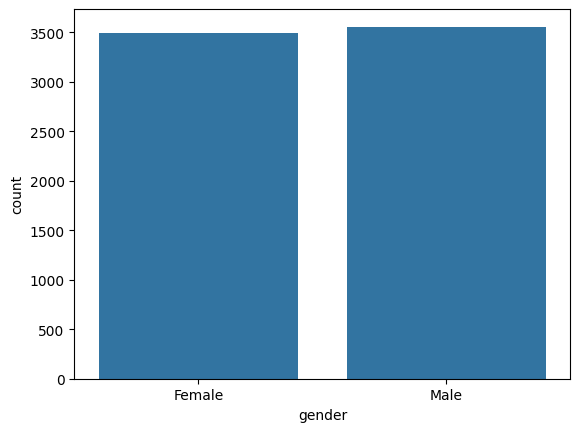

In [16]:
sns.countplot(x='gender' , data = df)

<Axes: xlabel='Partner', ylabel='count'>

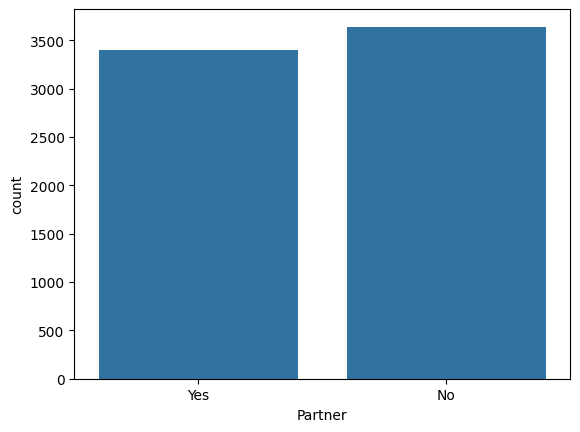

In [17]:
sns.countplot(x = 'Partner' , data=df)

<Axes: xlabel='Dependents', ylabel='count'>

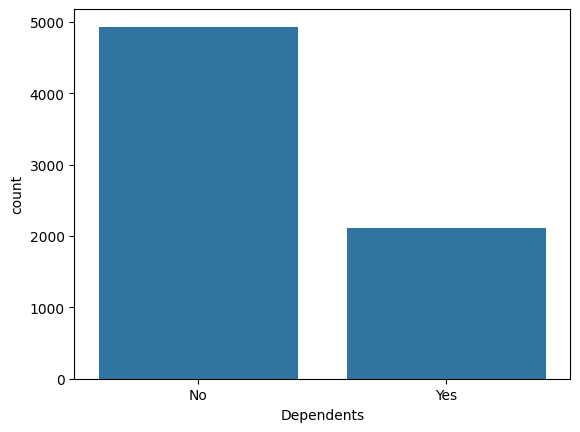

In [18]:
sns.countplot(x ='Dependents' , data = df)

<Axes: xlabel='Contract', ylabel='count'>

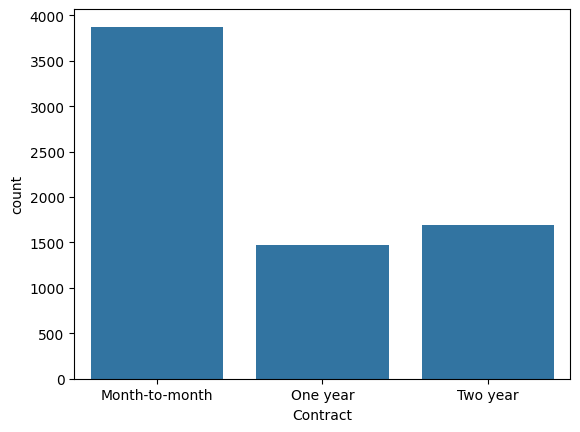

In [19]:
sns.countplot(x = 'Contract', data = df)

# BIVARIATE ANALYSIS

In [20]:
pd.crosstab(df['Contract'] , df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


<Axes: xlabel='Contract', ylabel='count'>

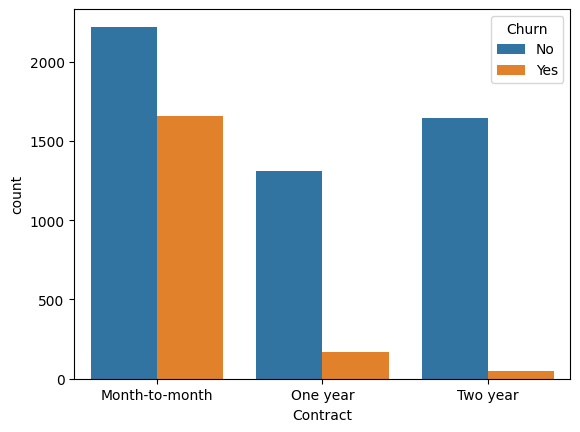

In [21]:
sns.countplot(x='Contract',hue='Churn',data=df)

<Axes: xlabel='Churn', ylabel='tenure'>

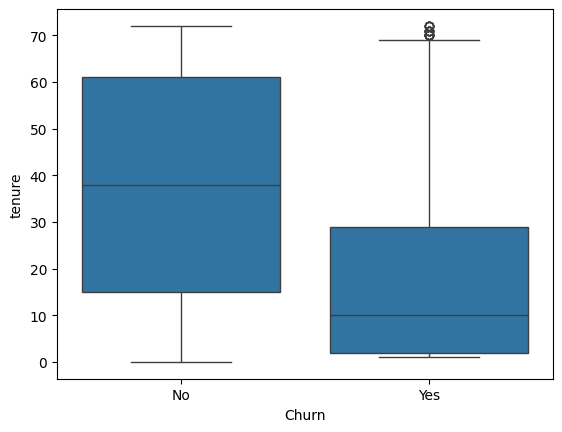

In [22]:
sns.boxplot(x='Churn',y='tenure',data=df)

# Insight

---


Customers with tenure < 12 months show significantly higher churn, indicating early lifecycle retention is a critical business risk.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

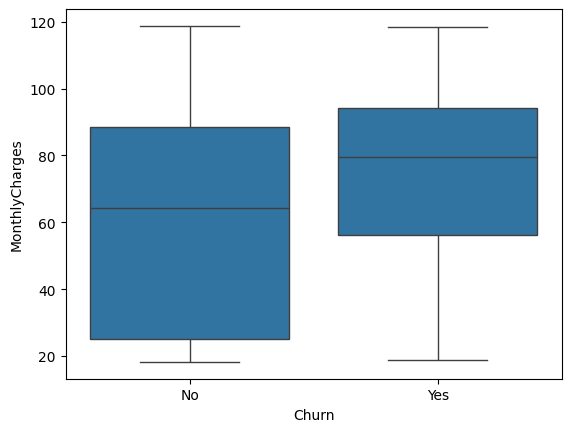

In [23]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)

# Insight

---


Customers who churn tend to have higher monthly charges compared to non-churned customers, suggesting pricing may be a key factor influencing churn behavior.

<Axes: xlabel='Churn', ylabel='TotalCharges'>

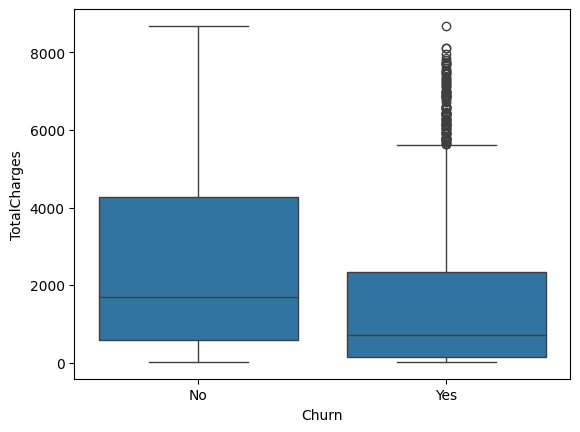

In [24]:
sns.boxplot(x='Churn',y='TotalCharges',data=df)

# Insight

---


Churn customers have low total charges as they are new customers

In [25]:
churned = df[df['Churn']=='Yes']
churned

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7021,1699-HPSBG,Male,0,No,No,12,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Electronic check,59.80,727.80,Yes
7026,8775-CEBBJ,Female,0,No,No,9,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes


In [26]:
revenue_lost = churned['MonthlyCharges'].sum()
revenue_lost

np.float64(139130.85)

<Axes: xlabel='Contract', ylabel='count'>

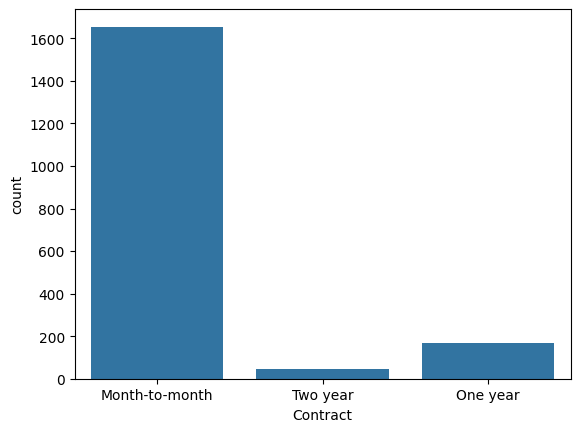

In [27]:
sns.countplot(x='Contract', data=churned)

In [30]:
not_churned = df[df['Churn']=='No']

In [31]:
revenue_generated = not_churned['MonthlyCharges'].sum()
revenue_generated

np.float64(316985.75)

<Axes: xlabel='Contract', ylabel='count'>

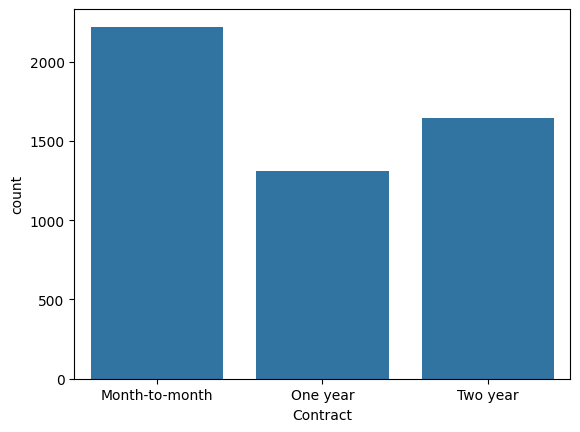

In [32]:
sns.countplot(x='Contract' , data = not_churned)

In [68]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-12','13-24','25-48','48+'])

In [34]:
df.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [35]:
df[df['Churn']=='Yes'].groupby('Contract')['MonthlyCharges'].sum()

Contract
Month-to-month    120847.10
One year           14118.45
Two year            4165.30
Name: MonthlyCharges, dtype: float64

# **Key Findings**

1. Month-to-month contracts experience the highest churn.
2. Customers with tenure below 12 months are at greatest risk.
3. Higher monthly charges are associated with increased churn.
4. Long-term customers demonstrate stronger retention.
5. Customer churn contributes to measurable revenue loss.

# **Business Recommendations**

1. Encourage customers to move to annual contracts.
2. Improve onboarding during the first year.
3. Introduce retention offers for high-charge customers.
4. Develop targeted campaigns for high-risk customer segments.
5. Monitor churn through dashboards and periodic reporting.

# **Conclusion**

Contract type, tenure, and monthly charges are key drivers of customer churn. By focusing retention efforts on new customers and promoting long-term contracts, businesses can reduce churn and improve revenue stability.

# LINK TO SQL

In [44]:
!pip install mysql-connector-python
!pip install pymsql sqlalchemy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement pymsql (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for pymsql


In [53]:
import mysql.connector
from mysql.connector import Error

In [59]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="mysql+mysqlconnector",
    username="root",
    password="Rajiwate@123",
    host="localhost",
    database="customer_churn"
)

engine = create_engine(url)

In [64]:
df.to_sql(
    name='customers',
    con=engine,
    if_exists='replace',
    index=False
)

print("Table created successfully!")

Table created successfully!


In [65]:
cursor.execute("SHOW TABLES")
print(cursor.fetchall())

[('customers',)]


In [66]:
df.to_csv('telco_churn_cleaned.csv', index=False)

In [73]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,25-48
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12
